# PRCP-1010: Insurance Claim Prediction

Submitted By: NASEEB KHAN

Course: (CDS)

# 1. Introduction

Insurance companies invest heavily in marketing campaigns to promote their products. However, not all customers are interested in purchasing insurance products. Random marketing strategies increase operational costs and reduce campaign efficiency.

This project focuses on developing a machine learning model that predicts whether a customer is likely to purchase an insurance product. The model helps the insurance marketing team identify high-potential customers and improve marketing effectiveness.

# 2. Problem Statement

Task 1

Develop a predictive model to identify customers who are likely to purchase an insurance product.

Task 2

Provide suggestions to the insurance marketing team to improve customer conversion and reduce unnecessary marketing efforts.

# 3. Dataset Description

The dataset was provided with anonymized feature names due to privacy concerns.

Attribute	Description:

Total Observations	    595,212

Total Features	        59

Target Variable	        target

Problem Type	        Binary Classification


Target Variable Meaning:

Target Value	     Meaning

0	                Customer will not buy insurance product

1	                Customer will buy insurance product

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,roc_auc_score

from imblearn.over_sampling import SMOTE


# Load Dataset

In [3]:
df=pd.read_csv("train.csv")

In [4]:
df.head()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,7,0,2,2,5,1,0,0,1,0,...,9,1,5,8,0,1,1,0,0,1
1,9,0,1,1,7,0,0,0,0,1,...,3,1,1,9,0,1,1,0,1,0
2,13,0,5,4,9,1,0,0,0,1,...,4,2,7,7,0,1,1,0,1,0
3,16,0,0,1,2,0,0,1,0,0,...,2,2,4,9,0,0,0,0,0,0
4,17,0,0,2,0,1,0,1,0,0,...,3,1,1,3,0,0,0,1,1,0


In [5]:
df.shape

(595212, 59)

In [6]:
df.columns

Index(['id', 'target', 'ps_ind_01', 'ps_ind_02_cat', 'ps_ind_03',
       'ps_ind_04_cat', 'ps_ind_05_cat', 'ps_ind_06_bin', 'ps_ind_07_bin',
       'ps_ind_08_bin', 'ps_ind_09_bin', 'ps_ind_10_bin', 'ps_ind_11_bin',
       'ps_ind_12_bin', 'ps_ind_13_bin', 'ps_ind_14', 'ps_ind_15',
       'ps_ind_16_bin', 'ps_ind_17_bin', 'ps_ind_18_bin', 'ps_reg_01',
       'ps_reg_02', 'ps_reg_03', 'ps_car_01_cat', 'ps_car_02_cat',
       'ps_car_03_cat', 'ps_car_04_cat', 'ps_car_05_cat', 'ps_car_06_cat',
       'ps_car_07_cat', 'ps_car_08_cat', 'ps_car_09_cat', 'ps_car_10_cat',
       'ps_car_11_cat', 'ps_car_11', 'ps_car_12', 'ps_car_13', 'ps_car_14',
       'ps_car_15', 'ps_calc_01', 'ps_calc_02', 'ps_calc_03', 'ps_calc_04',
       'ps_calc_05', 'ps_calc_06', 'ps_calc_07', 'ps_calc_08', 'ps_calc_09',
       'ps_calc_10', 'ps_calc_11', 'ps_calc_12', 'ps_calc_13', 'ps_calc_14',
       'ps_calc_15_bin', 'ps_calc_16_bin', 'ps_calc_17_bin', 'ps_calc_18_bin',
       'ps_calc_19_bin', 'ps_calc_20_bin'],


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 595212 entries, 0 to 595211
Data columns (total 59 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id              595212 non-null  int64  
 1   target          595212 non-null  int64  
 2   ps_ind_01       595212 non-null  int64  
 3   ps_ind_02_cat   595212 non-null  int64  
 4   ps_ind_03       595212 non-null  int64  
 5   ps_ind_04_cat   595212 non-null  int64  
 6   ps_ind_05_cat   595212 non-null  int64  
 7   ps_ind_06_bin   595212 non-null  int64  
 8   ps_ind_07_bin   595212 non-null  int64  
 9   ps_ind_08_bin   595212 non-null  int64  
 10  ps_ind_09_bin   595212 non-null  int64  
 11  ps_ind_10_bin   595212 non-null  int64  
 12  ps_ind_11_bin   595212 non-null  int64  
 13  ps_ind_12_bin   595212 non-null  int64  
 14  ps_ind_13_bin   595212 non-null  int64  
 15  ps_ind_14       595212 non-null  int64  
 16  ps_ind_15       595212 non-null  int64  
 17  ps_ind_16_

In [8]:
df.describe()

,id,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
count,5.952120e+05,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,...,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000,595212.000000
mean,7.438036e+05,0.036448,1.900378,1.358943,4.423318,0.416794,0.405188,0.393742,0.257033,0.163921,...,5.441382,1.441918,2.872288,7.539026,0.122427,0.627840,0.554182,0.287182,0.349024,0.153318
std,4.293678e+05,0.187401,1.983789,0.664594,2.699902,0.493311,1.350642,0.488579,0.436998,0.370205,...,2.332871,1.202963,1.694887,2.746652,0.327779,0.483381,0.497056,0.452447,0.476662,0.360295
min,7.000000e+00,0.000000,0.000000,-1.000000,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.719915e+05,0.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,4.000000,1.000000,2.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,7.435475e+05,0.000000,1.000000,1.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,1.000000,3.000000,7.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
75%,1.115549e+06,0.000000,3.000000,2.000000,6.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,7.000000,2.000000,4.000000,9.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000
max,1.488027e+06,1.000000,7.000000,4.000000,11.000000,1.000000,6.000000,1.000000,1.000000,1.000000,...,19.000000,10.000000,13.000000,23.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# Check Missing Values

In [9]:
df.isnull().sum()

id                0
target            0
ps_ind_01         0
ps_ind_02_cat     0
ps_ind_03         0
ps_ind_04_cat     0
ps_ind_05_cat     0
ps_ind_06_bin     0
ps_ind_07_bin     0
ps_ind_08_bin     0
ps_ind_09_bin     0
ps_ind_10_bin     0
ps_ind_11_bin     0
ps_ind_12_bin     0
ps_ind_13_bin     0
ps_ind_14         0
ps_ind_15         0
ps_ind_16_bin     0
ps_ind_17_bin     0
ps_ind_18_bin     0
ps_reg_01         0
ps_reg_02         0
ps_reg_03         0
ps_car_01_cat     0
ps_car_02_cat     0
ps_car_03_cat     0
ps_car_04_cat     0
ps_car_05_cat     0
ps_car_06_cat     0
ps_car_07_cat     0
ps_car_08_cat     0
ps_car_09_cat     0
ps_car_10_cat     0
ps_car_11_cat     0
ps_car_11         0
ps_car_12         0
ps_car_13         0
ps_car_14         0
ps_car_15         0
ps_calc_01        0
ps_calc_02        0
ps_calc_03        0
ps_calc_04        0
ps_calc_05        0
ps_calc_06        0
ps_calc_07        0
ps_calc_08        0
ps_calc_09        0
ps_calc_10        0
ps_calc_11        0


In [10]:
df=df.drop(columns='id')

# Why remove ID column?
# Because it is unique for every customer and has no predictive value.

In [11]:
df.head()

,target,ps_ind_01,ps_ind_02_cat,ps_ind_03,ps_ind_04_cat,ps_ind_05_cat,ps_ind_06_bin,ps_ind_07_bin,ps_ind_08_bin,ps_ind_09_bin,...,ps_calc_11,ps_calc_12,ps_calc_13,ps_calc_14,ps_calc_15_bin,ps_calc_16_bin,ps_calc_17_bin,ps_calc_18_bin,ps_calc_19_bin,ps_calc_20_bin
0,0,2,2,5,1,0,0,1,0,0,...,9,1,5,8,0,1,1,0,0,1
1,0,1,1,7,0,0,0,0,1,0,...,3,1,1,9,0,1,1,0,1,0
2,0,5,4,9,1,0,0,0,1,0,...,4,2,7,7,0,1,1,0,1,0
3,0,0,1,2,0,0,1,0,0,0,...,2,2,4,9,0,0,0,0,0,0
4,0,0,2,0,1,0,1,0,0,0,...,3,1,1,3,0,0,0,1,1,0


# Check Target Distribution

In [12]:
df['target'].value_counts()

target
0    573518
1     21694
Name: count, dtype: int64

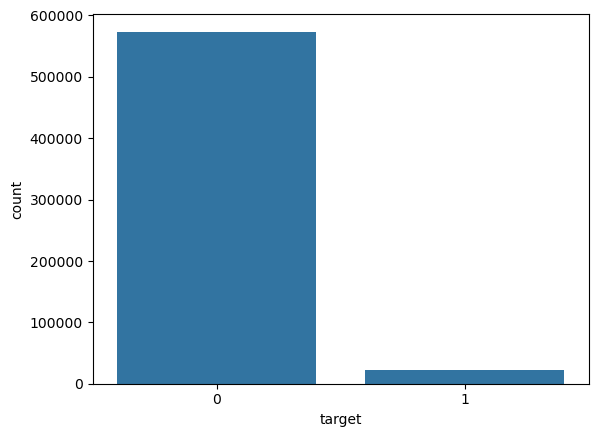

In [13]:
sns.countplot(x='target', data=df)
plt.show()

Most likely this dataset is imbalanced.
Example:
95% = 0,
 5% = 1
This means accuracy alone is NOT enough.

# Features and Target

In [14]:
X = df.drop(['target'], axis=1)  #target → output column

y = df['target']



# Train Test Split

In [15]:
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)   #stratify=y maintains class balance.


# Feature Scaling

In [16]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

# Handle Imbalanced Data Using SMOTE

In [17]:
sm = SMOTE(random_state=42)

X_train_sm, y_train_sm = sm.fit_resample(X_train_scaled, y_train)

# Why use SMOTE?
# Dataset was imbalanced, so SMOTE helps balance minority class samples.

# Build Models

# Logistic Regression

In [18]:
lr=LogisticRegression()
lr.fit(X_train_sm, y_train_sm)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [19]:
y_pred_lr = lr.predict(X_test_scaled)


In [20]:
print("Logistic Regression")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression
[[68131 46573]
 [ 1937  2402]]
              precision    recall  f1-score   support

           0       0.97      0.59      0.74    114704
           1       0.05      0.55      0.09      4339

    accuracy                           0.59    119043
   macro avg       0.51      0.57      0.41    119043
weighted avg       0.94      0.59      0.71    119043

Accuracy: 0.5925001890073335


# ROC-AUC Score
Very important for imbalanced datasets.

In [21]:
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]
roc_lr = roc_auc_score(y_test, y_prob_lr)
print("LR ROC-AUC:", roc_lr)

LR ROC-AUC: 0.606475638239866


# DecisionTreeClassifier

In [28]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train_sm,y_train_sm)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [29]:
 y_pred_dt=dt.predict(X_test_scaled)

In [30]:
print("DecisionTreeClassifier")
print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

DecisionTreeClassifier
[[79906 34798]
 [ 2815  1524]]
              precision    recall  f1-score   support

           0       0.97      0.70      0.81    114704
           1       0.04      0.35      0.07      4339

    accuracy                           0.68    119043
   macro avg       0.50      0.52      0.44    119043
weighted avg       0.93      0.68      0.78    119043

Accuracy: 0.684038540695379


In [31]:
# ROC-AUC Score
y_prob_dt = dt.predict_proba(X_test_scaled)[:,1]
roc_dt = roc_auc_score(y_test, y_prob_dt)
print("DT ROC-AUC:", roc_dt)

DT ROC-AUC: 0.5253666111302051


# Random Forest 

In [32]:
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(X_train_sm,y_train_sm)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [35]:
y_pred_rf=rf.predict(X_test_scaled)

In [36]:
print("RandomForestClassifier")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

RandomForestClassifier
[[114704      0]
 [  4338      1]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       1.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.98      0.50      0.49    119043
weighted avg       0.96      0.96      0.95    119043

Accuracy: 0.9635593861041808


In [37]:
# ROC-AUC Score
y_prob_rf = rf.predict_proba(X_test_scaled)[:,1]
roc_rf = roc_auc_score(y_test, y_prob_rf)
print("RF ROC-AUC:", roc_rf)

RF ROC-AUC: 0.5850476184624519


# XGBoost

In [2]:
!pip install xgboost

In [38]:
from xgboost import XGBClassifier

In [39]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train_sm, y_train_sm)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [40]:
 y_pred_xgb = xgb.predict(X_test_scaled)

In [41]:
print("XGBoost Model")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))

XGBoost Model
[[114704      0]
 [  4338      1]]
              precision    recall  f1-score   support

           0       0.96      1.00      0.98    114704
           1       1.00      0.00      0.00      4339

    accuracy                           0.96    119043
   macro avg       0.98      0.50      0.49    119043
weighted avg       0.96      0.96      0.95    119043

Accuracy: 0.9635593861041808


In [42]:
# ROC-AUC Score
y_prob_xgb = xgb.predict_proba(X_test_scaled)[:,1]
roc_xgb = roc_auc_score(y_test, y_prob_xgb)
print("XGB ROC-AUC:", roc_xgb)

XGB ROC-AUC: 0.6273485221204933


# Model Performance

Accuracy Scores

Model Accuracy:

Logistic Regression	         59.20%

Decision Tree	             68.40%

Random Forest	             96.35%

XGBoost	                    96.35%

# ROC-AUC Performance

Model ROC-AUC Score

Logistic Regression	  0.60

Decision Tree	      0.52

Random Forest	      0.58

XGBoost	              0.62

# Key Observations

The dataset was highly imbalanced.

High accuracy was misleading because predicting most samples as class 0 produced very high accuracy.

ROC-AUC and Recall were more reliable metrics for this project.

XGBoost achieved the best ROC-AUC score among all models.

Decision Tree showed poor generalization performance.

# Best Model Selection
Selected Model: XGBoost

Reasons for Selection

Better handling of imbalanced data

Highest ROC-AUC score

Strong ensemble learning capability

Good performance on structured tabular datasets

# Business Recommendations

1. Target High-Potential Customers

Use prediction scores to identify customers likely to purchase insurance products.

2. Personalized Marketing Campaigns

Provide customized offers and promotions to interested customers.

3. Reduce Marketing Costs

Avoid spending resources on customers with low purchase probability.

# Business Impact

The predictive model can help insurance companies:

Improve marketing efficiency

Increase sales conversion rates

Reduce operational costs

Make data-driven marketing decisions

Enhance customer targeting strategies

# Challenges Faced

1. Hidden Feature Names

Feature interpretation was limited due to anonymized data.

2. Severe Class Imbalance


Minority class prediction was difficult.

 3. Misleading Accuracy

High accuracy did not indicate good class separation.

# Conclusion

This project successfully developed a machine learning solution for predicting customer interest in insurance products.
Among all models tested, XGBoost achieved the best performance based on ROC-AUC evaluation. The proposed solution can help insurance companies optimize marketing campaigns, improve customer targeting, and reduce unnecessary operational costs.